

*  
*   Task 1: Data Understanding and Visualization


Classes found:
['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


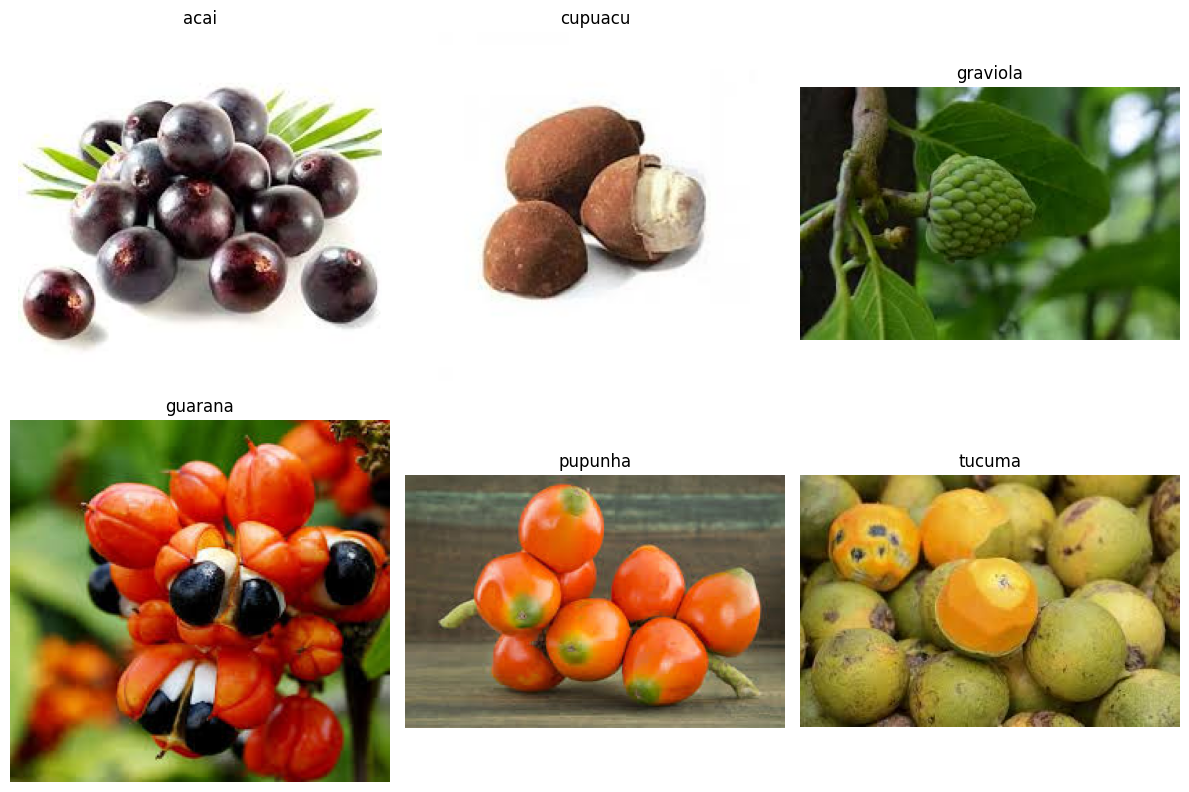

In [1]:
# =========================================
# TASK 1: DATA UNDERSTANDING AND VISUALIZATION
# =========================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Set dataset paths
train_dir = "/content/drive/MyDrive/Datasets/FruitinAmazon/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/Datasets/FruitinAmazon/FruitinAmazon/test"

# Get class names from train folder
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

print("Classes found:")
print(class_names)
print("Number of classes:", len(class_names))

# Select one random image from each class
sample_images = []
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    image_files = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]

    if len(image_files) > 0:
        random_image = random.choice(image_files)
        sample_images.append((class_name, os.path.join(class_path, random_image)))

# Display images in a grid with two rows
num_images = len(sample_images)
cols = int(np.ceil(num_images / 2))
rows = 2

plt.figure(figsize=(4 * cols, 8))

for i, (class_name, image_path) in enumerate(sample_images):
    img = Image.open(image_path)
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

Task 1B: Check for Corrupted Images

In [2]:
# =========================================
# TASK 1B: CHECK FOR CORRUPTED IMAGES
# =========================================

corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    for filename in os.listdir(class_path):
        image_path = os.path.join(class_path, filename)

        try:
            with Image.open(image_path) as img:
                img.verify()  # Verify image validity
        except (IOError, SyntaxError, OSError):
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f"Removed corrupted image: {image_path}")

if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")
else:
    print("\nTotal corrupted images removed:", len(corrupted_images))

No Corrupted Images Found.


Task 2: Loading and Preprocessing Image Data in Keras

In [3]:
# =========================================
# TASK 2: LOADING AND PREPROCESSING IMAGE DATA
# =========================================

import tensorflow as tf

# Define image and batch parameters
img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2
seed = 123

# Create normalization layer
rescale = tf.keras.layers.Rescaling(1./255)

# Create training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset="training",
    seed=seed
)

# Create validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset="validation",
    seed=seed
)

# Create test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=False
)

# Normalize datasets
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Improve performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# Display class names inferred by Keras
print("Class names:", train_ds.class_names if hasattr(train_ds, "class_names") else "Loaded")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names: Loaded


This task prepares the dataset for CNN training. Images are resized to the same shape, converted into batches, and normalized to pixel values between 0 and 1. The training set is split into training and validation subsets using validation_split.

Task 3: Implement a CNN

In [4]:
# =========================================
# TASK 3: BUILD CNN MODEL
# =========================================

from tensorflow import keras
from tensorflow.keras import layers

# Infer number of classes from training folders
num_classes = len(class_names)

# Build CNN model
model = keras.Sequential([
    # Input layer
    layers.Input(shape=(img_height, img_width, 3)),  # RGB images

    # Convolutional block 1
    layers.Conv2D(filters=32, kernel_size=(3, 3), strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # Convolutional block 2
    layers.Conv2D(filters=32, kernel_size=(3, 3), strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # Fully connected network
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),

    # Output layer
    layers.Dense(num_classes, activation="softmax")
])

# Print model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 4: Compile the Model

In [5]:
# =========================================
# TASK 4: COMPILE THE MODEL
# =========================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


Task 5: Train the Model

In [6]:
# =========================================
# TASK 5: TRAIN THE MODEL
# =========================================

epochs = 250

# Callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_cnn_model.h5",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

# Train model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.1809 - loss: 2.4050
Epoch 1: val_loss improved from None to 1.60751, saving model to best_cnn_model.h5



Epoch 1: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 427ms/step - accuracy: 0.1389 - loss: 2.4088 - val_accuracy: 0.3889 - val_loss: 1.6075
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.2924 - loss: 1.7798
Epoch 2: val_loss did not improve from 1.60751
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 319ms/step - accuracy: 0.2639 - loss: 1.7661 - val_accuracy: 0.0000e+00 - val_loss: 1.7983
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.2865 - loss: 1.7010
Epoch 3: val_loss did not improve from 1.60751
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 314ms/step - accuracy: 0.2917 - loss: 1.7016 - val_accuracy: 0.5000 - val_loss: 1.6898
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.5125 - loss: 1.6074
Epoch 4: val_loss improved from 1.60751 to 1.28569, saving model to best_cnn_model.h5



Epoch 4: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 377ms/step - accuracy: 0.5000 - loss: 1.5745 - val_accuracy: 0.7222 - val_loss: 1.2857
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.5264 - loss: 1.4068
Epoch 5: val_loss improved from 1.28569 to 1.19223, saving model to best_cnn_model.h5



Epoch 5: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 557ms/step - accuracy: 0.5694 - loss: 1.3663 - val_accuracy: 0.7778 - val_loss: 1.1922
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.6681 - loss: 1.0918
Epoch 6: val_loss did not improve from 1.19223
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 359ms/step - accuracy: 0.6528 - loss: 1.0862 - val_accuracy: 0.6111 - val_loss: 1.3102
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.7177 - loss: 0.7973
Epoch 7: val_loss improved from 1.19223 to 0.47233, saving model to best_cnn_model.h5



Epoch 7: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 326ms/step - accuracy: 0.7083 - loss: 0.8348 - val_accuracy: 0.9444 - val_loss: 0.4723
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.8493 - loss: 0.5241
Epoch 8: val_loss did not improve from 0.47233
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 326ms/step - accuracy: 0.8194 - loss: 0.5256 - val_accuracy: 0.7778 - val_loss: 1.1629
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.9368 - loss: 0.3294
Epoch 9: val_loss improved from 0.47233 to 0.29187, saving model to best_cnn_model.h5



Epoch 9: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 356ms/step - accuracy: 0.9028 - loss: 0.3349 - val_accuracy: 0.9444 - val_loss: 0.2919
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.9031 - loss: 0.2637
Epoch 10: val_loss did not improve from 0.29187
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 338ms/step - accuracy: 0.8750 - loss: 0.2812 - val_accuracy: 0.8333 - val_loss: 0.7614
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.9740 - loss: 0.1751
Epoch 11: val_loss did not improve from 0.29187
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 467ms/step - accuracy: 0.9583 - loss: 0.1587 - val_accuracy: 0.8333 - val_loss: 0.5164
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 1.0000 - loss: 0.0698
Epoch 12: val_loss improved from 0.29187 to 0.17250, saving model to best_cnn_model.h5



Epoch 12: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 540ms/step - accuracy: 1.0000 - loss: 0.0739 - val_accuracy: 0.8889 - val_loss: 0.1725
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 1.0000 - loss: 0.0403
Epoch 13: val_loss did not improve from 0.17250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 371ms/step - accuracy: 1.0000 - loss: 0.0465 - val_accuracy: 0.8889 - val_loss: 0.3636
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 1.0000 - loss: 0.0358
Epoch 14: val_loss did not improve from 0.17250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 300ms/step - accuracy: 1.0000 - loss: 0.0250 - val_accuracy: 0.8333 - val_loss: 0.6952
Epoch 15/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 1.0000 - loss: 0.0142
Epoch 15: val_loss did not improve from 0.17250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 335ms/step - accuracy: 1.0000 - loss: 0.0161 - val_accuracy: 0.8333 - val_loss: 0.7619
Epoch 16/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 1.0000 - loss: 0.012

Training data goes through the CNN.
Predictions are compared with true labels.
Loss is calculated.
Backpropagation updates weights.
ModelCheckpoint saves the best model.
EarlyStopping stops training if validation loss stops improving.

Task 5B: Plot Training and Validation Graphs

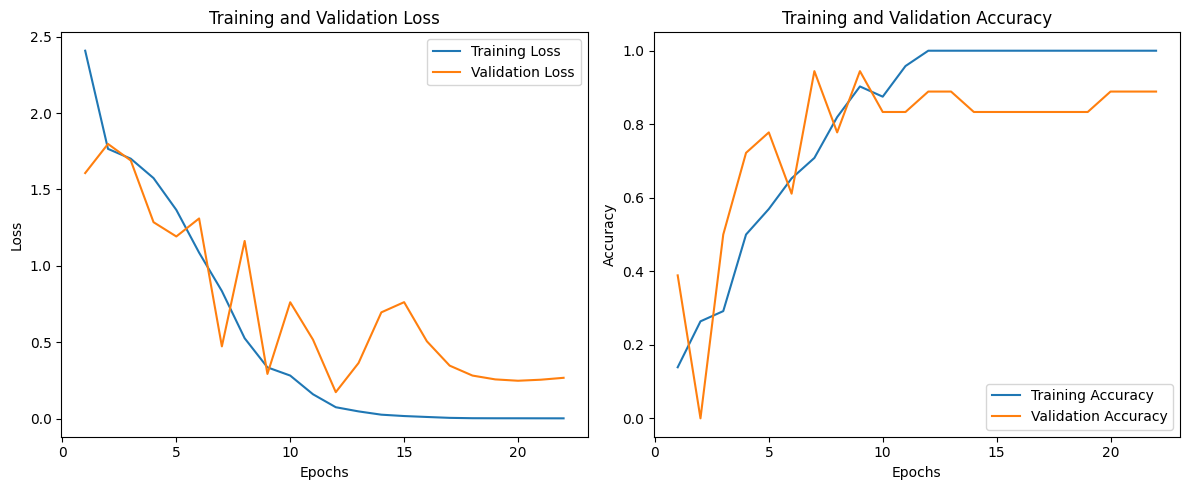

In [7]:
# =========================================
# TASK 5B: VISUALIZE TRAINING HISTORY
# =========================================

import matplotlib.pyplot as plt

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]
train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label="Training Loss")
plt.plot(range(1, len(val_loss) + 1), val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label="Training Accuracy")
plt.plot(range(1, len(val_acc) + 1), val_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

Task 6: Evaluate the Model

In [8]:
# =========================================
# TASK 6: EVALUATE THE MODEL
# =========================================

test_loss, test_acc = model.evaluate(test_ds, verbose=2)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

2/2 - 6s - 3s/step - accuracy: 0.7000 - loss: 0.7645
Test Loss: 0.7645
Test Accuracy: 0.7000


Task 7: Save and Load the Model

In [9]:
# =========================================
# TASK 7: SAVE AND LOAD THE MODEL
# =========================================

# Save model
model.save("fruit_cnn_model.h5")
print("Model saved successfully.")

# Load model
loaded_model = tf.keras.models.load_model("fruit_cnn_model.h5")
print("Model loaded successfully.")

# Re-evaluate loaded model
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=2)

print(f"Loaded Model Test Loss: {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy: {loaded_acc:.4f}")

Model saved successfully.
Model loaded successfully.
2/2 - 1s - 309ms/step - accuracy: 0.7000 - loss: 0.7645
Loaded Model Test Loss: 0.7645
Loaded Model Test Accuracy: 0.7000


model.save() stores the model architecture and weights.
load_model() restores it.
Evaluating again checks that the loaded model works correctly.

Task 7B: Predictions and Classification Report

In [11]:
# =========================================
# TASK 7B: PREDICTIONS AND CLASSIFICATION REPORT
# =========================================

from sklearn.metrics import classification_report

# Collect true labels and predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

# Print first 10 predictions
print("First 10 Predictions vs Actual:")
for i in range(min(10, len(y_true))):
    print(f"Predicted: {y_pred[i]}, Actual: {y_true[i]}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

First 10 Predictions vs Actual:
Predicted: 0, Actual: 0
Predicted: 1, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 1, Actual: 1
Predicted: 1, Actual: 1
Predicted: 1, Actual: 1
Predicted: 1, Actual: 1
Predicted: 1, Actual: 1

Classification Report:
              precision    recall  f1-score   support

        acai       0.67      0.80      0.73         5
     cupuacu       0.71      1.00      0.83         5
    graviola       0.83      1.00      0.91         5
     guarana       1.00      0.40      0.57         5
     pupunha       0.75      0.60      0.67         5
      tucuma       0.40      0.40      0.40         5

    accuracy                           0.70        30
   macro avg       0.73      0.70      0.68        30
weighted avg       0.73      0.70      0.68        30



model.predict() returns class probabilities.
np.argmax(..., axis=1) picks the class with the highest probability.
classification_report() summarizes model performance using:
precision
recall
F1-score
support